<h1>Tarea 3 Análisis de correlación </h1>
    <h3 style="color:blue">Roberto Gaona Juárez</h3>

<b>1. Cargue los datos en Python usando Pandas y muestre los primeros 10 registros</b>

In [1]:
pip install pingouin

In [2]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Preprocesado y análisis
# ==============================================================================
import statsmodels.api as sm
import pingouin as pg
from scipy import stats
from scipy.stats import pearsonr

# Configuración matplotlib
# ==============================================================================
plt.style.use('ggplot')

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [4]:
datos = pd.read_csv("2021_10_EstMeteorologica.csv", sep=';',decimal=',')

In [5]:
datos.head(10)

,No,Date,Time,ColdJunc0,PowerVolt,PowerKind,WS(ave),WD(ave),WS(max),WD(most),WS(inst_m),WD(inst_m),Max_time,Solar_rad,TEMP,Humidity,Rainfall,Bar_press.,Soil_temp
0,92793,1/10/2021,0:00:00,22.6,13.0,2,0.4,19,0.9,NE,1.9,43,23:50:41,0.0,22.5,82.39,0.0,1000.0,0.0
1,92794,1/10/2021,0:10:00,22.5,13.0,2,1.0,131,1.0,ESE,4.3,161,0:04:57,0.0,22.3,84.09,0.0,1000.0,0.0
2,92795,1/10/2021,0:20:00,22.5,13.0,2,0.8,166,1.0,ESE,3.7,145,0:13:00,0.0,22.7,81.99,0.0,1000.0,0.0
3,92796,1/10/2021,0:30:00,22.5,13.0,2,0.7,205,0.8,WSW,3.1,160,0:25:55,0.0,22.2,84.29,0.0,1000.0,0.0
4,92797,1/10/2021,0:40:00,22.5,12.9,2,0.6,134,0.7,E,4.3,121,0:35:35,0.0,21.8,87.90,0.0,999.7,0.0
5,92798,1/10/2021,0:50:00,22.4,13.0,2,0.2,124,0.6,SSE,1.9,51,0:47:12,0.0,21.6,89.40,0.0,999.6,0.0
6,92799,1/10/2021,1:00:00,22.2,13.0,2,0.8,7,0.8,NNE,2.5,54,0:51:29,0.0,21.5,90.20,0.0,999.2,0.0
7,92800,1/10/2021,1:10:00,22.1,12.9,2,0.9,52,0.9,NE,5.5,291,1:09:59,0.0,21.4,91.10,0.0,999.1,0.0
8,92801,1/10/2021,1:20:00,22.0,12.9,2,0.9,206,1.1,SSW,5.5,215,1:11:09,0.0,21.2,92.60,0.0,999.1,0.0
9,92802,1/10/2021,1:30:00,21.9,13.0,2,0.6,152,0.9,SE,3.7,145,1:20:30,0.0,21.2,93.60,0.0,999.1,0.0


<b>3.Este archivo contiene muchas columnas que no ocupamos por lo que extraeremos
solo las columnas de interés:</b>

In [6]:
sensor_EM = ["TEMP","Humidity","Solar_rad","Bar_press."]
subdatos=datos[sensor_EM].copy()
subdatos

,TEMP,Humidity,Solar_rad,Bar_press.
0,22.5,82.39,0.0,1000.0
1,22.3,84.09,0.0,1000.0
2,22.7,81.99,0.0,1000.0
3,22.2,84.29,0.0,1000.0
4,21.8,87.90,0.0,999.7
...,...,...,...,...
4459,22.7,88.70,0.0,1002.7
4460,22.7,88.80,0.0,1002.7
4461,22.9,88.80,0.0,1003.1
4462,22.8,88.40,0.0,1003.1


 <b>4.-Realice un diagrama de dispersión (scatterplot) para intuir si existe relación lineal o
monotónica entre las columnas:
• subdatos.TEMP subdatos.Humidity
• subdatos.Solar_rad subdatos.TEMP</b>

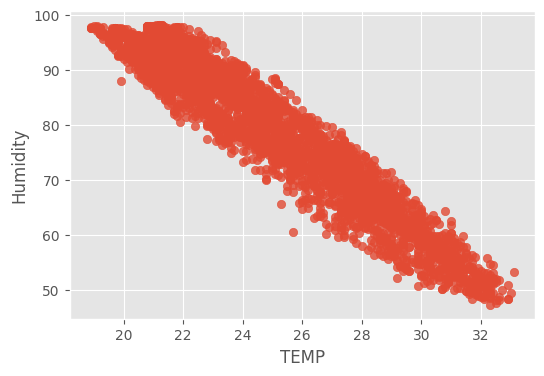

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.scatter(x=datos.TEMP, y=datos.Humidity, alpha= 0.8)
ax.set_xlabel('TEMP')
ax.set_ylabel('Humidity');

<p>Nota:Diagrama de dispersion TEMP Y Humidity</p>

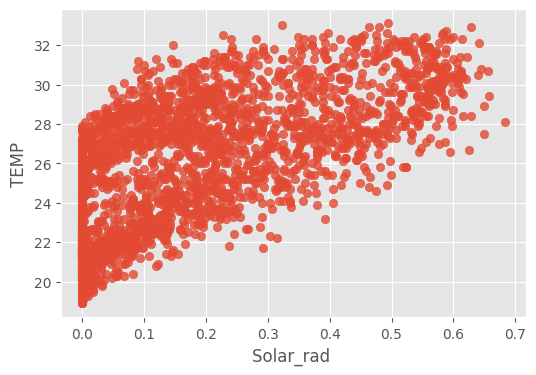

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.scatter(x=datos.Solar_rad, y=datos.TEMP, alpha= 0.8)
ax.set_xlabel('Solar_rad ')
ax.set_ylabel('TEMP');

<p>Nota:Diagrama de dispersion Solar_rad Y TEMP</p>

<b>5.Realice el gráfico de distribución y el gráfico Q-Q de las columnas TEMP y Humidity
para descartar el coeficiente Pearson, pues los datos no cumplen con el requisito de
la distribución normal.</b>

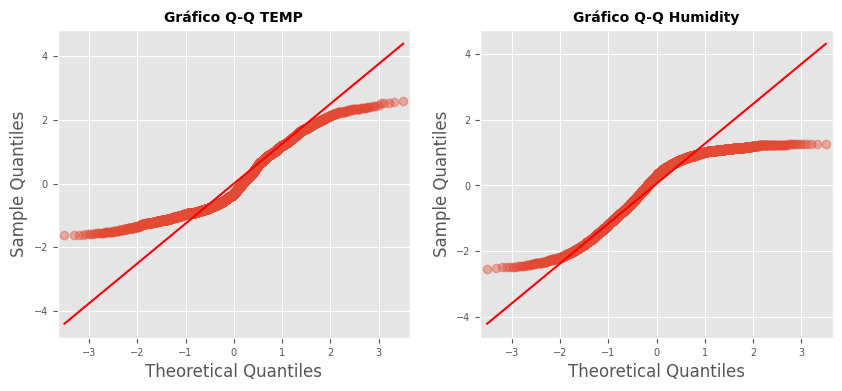

In [8]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sm.qqplot(
    datos.TEMP,
    fit   = True,
    line  = 'q',
    alpha = 0.4,
    lw    = 2,
    ax    = axs[0]
)
axs[0].set_title('Gráfico Q-Q TEMP', fontsize = 10, fontweight = "bold")
axs[0].tick_params(labelsize = 7)

sm.qqplot(
    datos.Humidity ,
    fit   = True,
    line  = 'q',
    alpha = 0.4,
    lw    = 2,
    ax    = axs[1]
)
axs[1].set_title('Gráfico Q-Q Humidity', fontsize = 10, fontweight = "bold")
axs[1].tick_params(labelsize = 7)

<b>6.Obtenga los coeficientes de correlación spearman y kendall y el p-value para las
columnas TEMP y Humidity (puede usar Scypy o Pingouin).
</b>

In [10]:
display(pg.corr(datos['TEMP'], datos['Humidity'], method='spearman'))
display(pg.corr(datos['TEMP'], datos['Humidity'], method='kendall'))

,n,r,CI95%,p-val,power
spearman,4464,-0.916714,"[-0.92, -0.91]",0.0,1.0


,n,r,CI95%,p-val,power
kendall,4464,-0.759432,"[-0.77, -0.75]",0.0,1.0


<b>7. Indique el nivel de correlación de estas columnas y que significa que el p-value sea 0.
</b>

<p>Los test estadísticos muestran una correlación lineal entre moderada y alta, con claras evidencias estadísticas de que la relación observada no se debe al azar (pvalue≈0).</p>

<b>8. Obtenga la matriz de correlación por el método spearman.</b>

In [11]:
corr_matrix = datos.corr(method='spearman')
corr_matrix

,No,ColdJunc0,PowerVolt,PowerKind,WS(ave),WD(ave),WS(max),WS(inst_m),WD(inst_m),Solar_rad,TEMP,Humidity,Rainfall,Bar_press.,Soil_temp
No,1.000000,0.111649,0.028879,NaN,0.092505,0.112337,0.092457,0.099989,0.091809,-0.025543,0.155578,0.047180,0.005965,0.434471,0.021332
ColdJunc0,0.111649,1.000000,0.668026,NaN,0.310802,-0.400005,0.303719,0.175766,-0.362584,0.785074,0.982897,-0.926595,-0.010966,-0.243948,0.935965
PowerVolt,0.028879,0.668026,1.000000,NaN,0.018178,-0.223724,0.006823,-0.088665,-0.196749,0.776570,0.636506,-0.615696,-0.021399,0.028826,0.603592
PowerKind,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WS(ave),0.092505,0.310802,0.018178,NaN,1.000000,-0.032884,0.958266,0.918744,-0.071461,-0.003455,0.289500,-0.271525,-0.015812,-0.255037,0.263875
WD(ave),0.112337,-0.400005,-0.223724,NaN,-0.032884,1.000000,-0.035401,0.054289,0.703420,-0.345203,-0.418560,0.427616,-0.024818,0.294388,-0.419438
WS(max),0.092457,0.303719,0.006823,NaN,0.958266,-0.035401,1.000000,0.900255,-0.069477,-0.012272,0.284175,-0.268505,-0.018866,-0.253887,0.256707
WS(inst_m),0.099989,0.175766,-0.088665,NaN,0.918744,0.054289,0.900255,1.000000,0.015018,-0.146197,0.156862,-0.129463,-0.021230,-0.216012,0.125990
WD(inst_m),0.091809,-0.362584,-0.196749,NaN,-0.071461,0.703420,-0.069477,0.015018,1.000000,-0.306650,-0.378900,0.379515,-0.025050,0.264520,-0.373090
Solar_rad,-0.025543,0.785074,0.776570,NaN,-0.003455,-0.345203,-0.012272,-0.146197,-0.306650,1.000000,0.750705,-0.734066,-0.014088,-0.080235,0.783914


<b>9. Muestre la matriz de correlación en el formato de tabla larga (tidy).</b>

In [12]:
def tidy_corr_matrix(corr_mat):
    corr_mat = corr_mat.stack().reset_index()
    corr_mat.columns = ['variable_1','variable_2','r']
    corr_mat = corr_mat.loc[corr_mat['variable_1'] != corr_mat['variable_2'], :]
    corr_mat['abs_r'] = np.abs(corr_mat['r'])
    corr_mat = corr_mat.sort_values('abs_r', ascending=False)
    
    return(corr_mat)

tidy_corr_matrix(corr_matrix).head(10)

,variable_1,variable_2,r,abs_r
127,TEMP,ColdJunc0,0.982897,0.982897
23,ColdJunc0,TEMP,0.982897,0.982897
47,WS(ave),WS(max),0.958266,0.958266
73,WS(max),WS(ave),0.958266,0.958266
27,ColdJunc0,Soil_temp,0.935965,0.935965
183,Soil_temp,ColdJunc0,0.935965,0.935965
141,Humidity,ColdJunc0,-0.926595,0.926595
24,ColdJunc0,Humidity,-0.926595,0.926595
139,TEMP,Soil_temp,0.922371,0.922371
191,Soil_temp,TEMP,0.922371,0.922371


<b>10.Muestre el Heatmap matriz de correlaciones.</b>

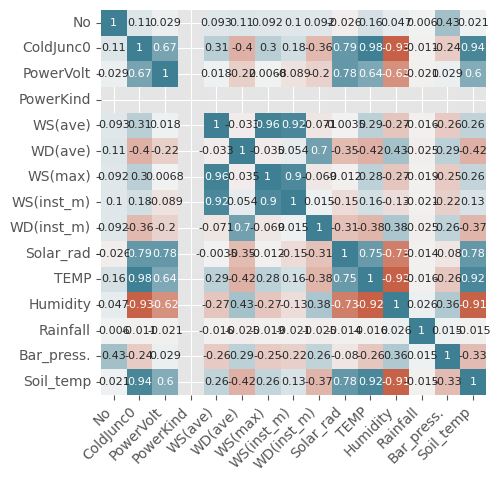

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

sns.heatmap(
    corr_matrix,
    annot     = True,
    cbar      = False,
    annot_kws = {"size": 8},
    vmin      = -1,
    vmax      = 1,
    center    = 0,
    cmap      = sns.diverging_palette(20, 220, n=200),
    square    = True,
    ax        = ax
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation = 45,
    horizontalalignment = 'right',
)

ax.tick_params(labelsize = 10)